# Apply the normalized nearest neighbor measure of mosaic tiling

Apply the mosaic tiling measure of Ravi et al. (2018) for Supp Fig. 5.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import torch
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse, Rectangle, ConnectionPatch, Circle
import seaborn as sns
from scipy.stats import ks_2samp

from brainbox import tuning
from retina import train, analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%reload_ext autoreload
%autoreload 2

In [2]:
root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")

In [3]:
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

In [4]:
torch.manual_seed(0)
rf_query = analysis.RFQuery(root, model)

INFO:util:Processing batch 0 out of 4...


INFO:util:Processing batch 1 out of 4...


INFO:util:Processing batch 2 out of 4...


INFO:util:Processing batch 3 out of 4...


INFO:gaussian:CC criteria exclusion 219


INFO:gaussian:Location criteria exclusion 38


INFO:gaussian:Envelope criteria exclusion 12


In [5]:

def plot_mosaic(cell_type, color, dx, dy, spec, fig):
    ax = plt.Subplot(fig, spec)
    fig.add_subplot(ax)
    q = rf_query.params_df["type"] == cell_type
    subparams_df = rf_query.params_df[q]
    
    ells = []
    for i in range(len(subparams_df)): #idx,idx+1,1
        x0 = subparams_df.iloc[i]["x0"]
        y0 = 20 - subparams_df.iloc[i]["y0"]
        sigmax = subparams_df.iloc[i]["sigmax"]
        sigmay = subparams_df.iloc[i]["sigmay"]
        p = subparams_df.iloc[i]["p"]
        ells.append(Ellipse(xy=(x0, y0),
                    width=1.5*sigmax, height=1.5*sigmay,
                    angle=-p*45, ec="black", fc="gray", linewidth=1.5))
    
    for e in ells:
        ax.add_artist(e)
        e.set_clip_box(ax.bbox)
        e.set_alpha(0.7)
        e.set_facecolor(color)
    
    ax.set_xlim(0+dx, 20+dx)
    ax.set_ylim(0+dy, 20+dy)
    ax.set_xticks([])
    ax.set_yticks([])
    
    for ax_name in ["left", "right", "bottom", "top"]:
        ax.spines[ax_name].set_visible(False)    
    
    return ax
    
fig_spec = gridspec.GridSpec(1, 2, wspace=0.4, hspace=0, width_ratios=[0.4, 1])
fig_spec2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=fig_spec[1], width_ratios=[1.5, 1], wspace=0.5)
mosaic_spec = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=fig_spec2[1], width_ratios=[1, 1], wspace=0.2)

Sampling fake populations...


<Figure size 640x480 with 0 Axes>

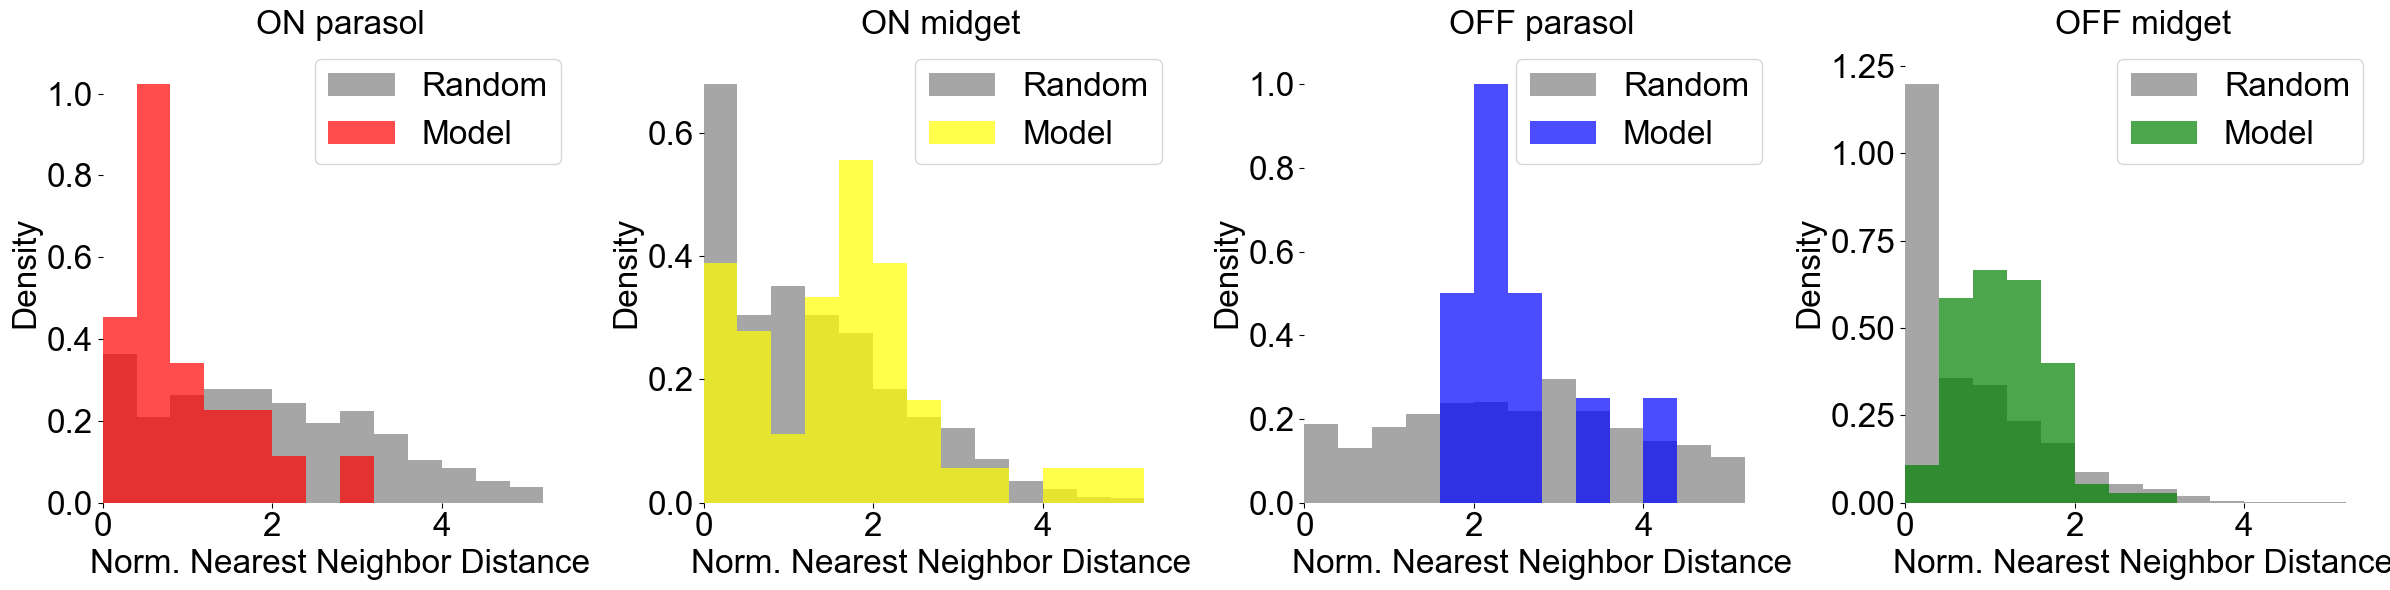


KS Test Results for Each Cell Type:
Cell Type 0: KS Statistic = 0.4465, p-value = 1.6123e-04
Cell Type 2: KS Statistic = 0.2401, p-value = 9.1011e-03
Cell Type 1: KS Statistic = 0.3579, p-value = 1.1898e-01
Cell Type 3: KS Statistic = 0.4520, p-value = 4.6572e-18


In [6]:
#Plot distributions of mosaic measures for each cell type

doplots = False

def ellipse_edge_point(x0, y0, sigmax, sigmay, angle_deg, dx, dy):
    norm = np.hypot(dx, dy) 
    dx /= norm
    dy /= norm
    theta = np.deg2rad(angle_deg) 
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    dx_rot = dx * cos_t + dy * sin_t
    dy_rot = -dx * sin_t + dy * cos_t

    scale = 1 / np.sqrt((dx_rot / sigmax) ** 2 + (dy_rot / sigmay) ** 2)
    return x0 + dx * scale, y0 + dy * scale

def plot_mosaic_and_nnnd(cell_type, color, dx_offset, dy_offset, spec, fig, subparams_df, plot=doplots):
    nnnd_list = np.zeros(len(subparams_df))  
    ax = None
    if plot:
        ax = plt.Subplot(fig, spec)  
        fig.add_subplot(ax)

    for i in range(len(subparams_df)):

        x0 = subparams_df.iloc[i]["x0"]
        y0 = 20 - subparams_df.iloc[i]["y0"]

        dists = [np.hypot(subparams_df.iloc[j]["x0"] - x0,
                          20 - subparams_df.iloc[j]["y0"] - y0) if i != j else np.inf
                 for j in range(len(subparams_df))]

        j_min = np.argmin(dists)  

        x1 = subparams_df.iloc[j_min]["x0"]
        y1 = 20 - subparams_df.iloc[j_min]["y0"]

        sigmax0, sigmay0 = subparams_df.iloc[i]["sigmax"], subparams_df.iloc[i]["sigmay"]
        angle0 = -subparams_df.iloc[i]["p"] * 45
        sigmax1, sigmay1 = subparams_df.iloc[j_min]["sigmax"], subparams_df.iloc[j_min]["sigmay"]
        angle1 = -subparams_df.iloc[j_min]["p"] * 45

        dx_line, dy_line = x1 - x0, y1 - y0

        edge_x0, edge_y0 = ellipse_edge_point(x0, y0, sigmax0 / 2, sigmay0 / 2, angle0, dx_line, dy_line)
        edge_x1, edge_y1 = ellipse_edge_point(x1, y1, sigmax1 / 2, sigmay1 / 2, angle1, -dx_line, -dy_line)

        dist0 = np.hypot(edge_x0 - x0, edge_y0 - y0)
        dist1 = np.hypot(edge_x1 - x1, edge_y1 - y1)
        distel = np.hypot(x1 - x0, y1 - y0)
        if distel>0:
            nnnd_list[i] = 2 * distel / (dist0 + dist1)
        else:
            nnnd_list[i] = 0

        if plot:
            ell0 = Ellipse((x0, y0), width=sigmax0, height=sigmay0, angle=angle0,
                           fc=color, ec="black", linewidth=1.5, alpha=0.7)
            ell1 = Ellipse((x1, y1), width=sigmax1, height=sigmay1, angle=angle1,
                           fc=color, ec="black", linewidth=1.5, alpha=0.7)
            ax.add_patch(ell0)
            ax.add_patch(ell1)

            line = ConnectionPatch((x0, y0), (x1, y1), coordsA="data", coordsB="data",
                                   axesA=ax, axesB=ax, color="gray")
            ax.add_artist(line)

            ax.add_patch(Circle((edge_x0, edge_y0), radius=0.15, color="gray", zorder=10))
            ax.add_patch(Circle((edge_x1, edge_y1), radius=0.15, color="gray", zorder=10))

    if plot:
        ax.set_xlim(0 + dx_offset, 20 + dx_offset)
        ax.set_ylim(0 + dy_offset, 20 + dy_offset)
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ["left", "right", "bottom", "top"]:
            ax.spines[side].set_visible(False)

    return ax, nnnd_list

def plot_histogram(nnnd_list, color, cell_type, filename):
    plt.figure(figsize=(10, 6))
    bins = np.arange(0, 5.6, 0.4)
    plt.hist(nnnd_list, bins=bins, alpha=0.7, color=color)
    plt.title(f'Histogram of Nearest Neighbor Distance (NNND) for Cell Type {cell_type}')
    plt.xlabel('Nearest Neighbor Distance (NNND)')
    plt.ylabel('Frequency')
    plt.xlim(0, 5.5)
    plt.ylim(0, np.max(np.histogram(nnnd_list, bins=bins)[0]) * 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(filename, format="svg", transparent=False, bbox_inches="tight")
    plt.show()


if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list0 = plot_mosaic_and_nnnd(0, "red", 0, 0, mosaic_spec[0, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 0])
if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list1 = plot_mosaic_and_nnnd(2, "yellow", 0, 0, mosaic_spec[1, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 2])
if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list2 = plot_mosaic_and_nnnd(1, "blue", 0, 0, mosaic_spec[2, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 1])
if doplots:
    fig = plt.figure(figsize=(100, 50))
else:
    fig = None
ax, nnnd_list3 = plot_mosaic_and_nnnd(3, "green", 0, 0, mosaic_spec[3, 1], fig,
                                      rf_query.params_df[rf_query.params_df["type"] == 3])

plt.savefig(f"{root}/figures/fig3/main_nnnd.svg", format="svg", transparent=False, bbox_inches="tight")

if doplots:
    plot_histogram(nnnd_list0, "red", 0, f"{root}/figures/fig3/nnnd_histogram_cell_type_0.svg")
    plot_histogram(nnnd_list1, "yellow", 1, f"{root}/figures/fig3/nnnd_histogram_cell_type_2.svg")
    plot_histogram(nnnd_list2, "blue", 2, f"{root}/figures/fig3/nnnd_histogram_cell_type_1.svg")
    plot_histogram(nnnd_list3, "green", 3, f"{root}/figures/fig3/nnnd_histogram_cell_type_3.svg")


def generate_fake_populations_and_compute_nnnds(rf_query, nnnd_list0, nnnd_list1,
                                                nnnd_list2, nnnd_list3, num_iterations=10,
                                                plot=doplots, verbose=False):
    all_cells_df = rf_query.params_df.copy()
    
    fake_nnnd_lists_by_type = {ctype: [] for ctype in [0, 2, 1, 3]} 

    print("Sampling fake populations...")
    for iteration in range(num_iterations):
        if verbose:
            print(f"Fake iteration {iteration + 1}")
        
        for idx, (ctype, color, dx, dy) in enumerate(zip(
            [0, 2, 1, 3],
            ["red", "yellow", "blue", "green"],
            [0, 0, 0, 0],
            [0, 0, 0, 0]
        )):

            num_cells_of_type = len(rf_query.params_df[rf_query.params_df["type"] == ctype])

            fake_cells_df = all_cells_df.sample(
                num_cells_of_type, replace=True
            )

            if plot:
                fig = plt.figure(figsize=(100, 50)) if iteration == 0 else None
                doplot = (iteration == 0)
            else:
                fig = None
                doplot = False

            ax, nnnds = plot_mosaic_and_nnnd(
                ctype, color, dx, dy, mosaic_spec[idx, 1],
                fig, fake_cells_df, plot=doplot
            )
            
            fake_nnnd_lists_by_type[ctype].extend(nnnds)

    fake_nnnd_lists_flat = {ctype: np.array(fake_nnnd_lists_by_type[ctype]) for ctype in fake_nnnd_lists_by_type}

    fake_counts_flat = {ctype: len(arr) for ctype, arr in fake_nnnd_lists_flat.items()}
    if verbose:
        print(fake_counts_flat)

    cell_types = ["ON parasol", "ON midget", "OFF parasol", "OFF midget"]

    ks_test_results = {}

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))  
    
    for idx, (ctype, color, real_nnnd_list) in enumerate(zip([0, 2, 1, 3], ["red", "yellow", "blue", "green"], [nnnd_list0, nnnd_list1, nnnd_list2, nnnd_list3])):

        fake_nnnd_list = fake_nnnd_lists_flat[ctype] 

        real_nnnd_list = np.asarray(real_nnnd_list, dtype=float)#
        fake_nnnd_list = np.asarray(fake_nnnd_list, dtype=float)#

        real_nnnd_list = real_nnnd_list[np.isfinite(real_nnnd_list)]#
        fake_nnnd_list = fake_nnnd_list[np.isfinite(fake_nnnd_list)]#

        if len(real_nnnd_list) < 2 or len(fake_nnnd_list) < 2:#
            ks_statistic, p_value = np.nan, np.nan#
        else:#
            ks_statistic, p_value = ks_2samp(real_nnnd_list, fake_nnnd_list)#

        ks_statistic, p_value = ks_2samp(real_nnnd_list, fake_nnnd_list)
        
        ks_test_results[ctype] = {'ks_statistic': ks_statistic, 'p_value': p_value}
        
        if verbose:
            print(f"KS Test for Cell Type {ctype}: KS Statistic = {ks_statistic:.4f}, p-value = {p_value:.4e}")

        ax = axes[idx]  
        bins = np.arange(0, 5.6, 0.4)
        
        n_fake, bins_fake, _ = ax.hist(fake_nnnd_list, bins=bins, alpha=0.7, color="gray",
                                       label="Random", density=True)
        
        n_real, bins_real, _ = ax.hist(real_nnnd_list, bins=bins_fake, alpha=0.7, color=color,
                                       label="Model", density=True)
        
        ax.set_title(f'{cell_types[idx]}', fontsize=24)  
        ax.set_xlabel('Norm. Nearest Neighbor Distance', fontsize=24)  
        ax.set_ylabel('Density', fontsize=24) 
        ax.set_xlim(0, 5.6)
        ax.set_ylim(0, np.max([n_fake.max(), n_real.max()]) * 1.1) 
        ax.grid(False)  
        ax.set_frame_on(False) 
        ax.legend(fontsize=24)  
        ax.tick_params(axis='both', which='major', labelsize=24)  

    plt.tight_layout()
    plt.savefig(f"{root}/figures/fig3/nnnd_histograms_row.png", format="png", transparent=False,
                bbox_inches="tight")
    plt.show()
    
    return ks_test_results

torch.manual_seed(0)
ks_test_results = generate_fake_populations_and_compute_nnnds(rf_query, nnnd_list0, nnnd_list1,
                                                              nnnd_list2, nnnd_list3, num_iterations=1000)

print("\nKS Test Results for Each Cell Type:")
for ctype, results in ks_test_results.items():
    print(f"Cell Type {ctype}: KS Statistic = {results['ks_statistic']:.4f}, p-value = {results['p_value']:.4e}")